# Musica

Notebook simple pour entraîner, évaluer et tester le modèle de reconnaissance d'accords.


## 0. Imports

On charge les bibliothèques et les classes utiles.


In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

from musica.modeling import (
    ROOTS,
    ChordEvaluator,
    ChordPredictor,
    ChordTrainer,
    FeatureExtractor,
    MusicaConfig,
    prepare_data,
)


## 1. Configuration

Les paramètres viennent de `musica.toml`.


In [11]:
config = MusicaConfig.load()
config

2026-07-10 09:04:16.800 | INFO     | musica.config:load:230 - Chargement de la configuration: musica.toml
2026-07-10 09:04:16.802 | INFO     | musica.config:load:233 - Configuration chargee: epochs=60, batch_size=32, lr=0.001, force_retrain=False


MusicaConfig(general=GeneralConfig(seed=0), training=TrainingConfig(epochs=60, batch_size=32, learning_rate=0.001, force_retrain=False, val_ratio=0.15, test_ratio=0.15), features=FeatureConfig(sample_rate=22050, target_duration=1.5, hop_length=512, bins_per_octave=12, n_chroma=12), prediction=PredictionConfig(top_k=3), paths=PathConfig(dataset_dir=PosixPath('audio/chords'), logs_dir=PosixPath('logs'), midi_output_dir=PosixPath('audio/chords/midi'), clean_output_dir=PosixPath('audio/chords/clean'), noise_download_dir=PosixPath('assets/noises/internet'), noisy_output_dir=PosixPath('audio/chords/noisy'), realistic_output_dir=PosixPath('audio/chords/realistic'), transposed_output_dir=PosixPath('audio/chords/transposed'), recorded_audio_dir=PosixPath('audio/chords/recorded'), audio_manifest_path=PosixPath('audio/manifest.csv')), examples=ExampleAudioConfig(directory=PosixPath('examples'), extensions=('.wav', '.mp3', '.flac', '.ogg', '.m4a', '.aiff', '.aif')), model=ModelConfig(architecture=

## 2. Préparer les données

On charge les WAV, on crée les splits et on extrait les features Chroma-CQT.


2026-07-10 09:04:16.837 | INFO     | musica.modeling.preparation:prepare_data:15 - Preparation des donnees
2026-07-10 09:04:16.838 | INFO     | musica.modeling.dataset:discover:34 - Recherche des fichiers WAV dans /Users/raharison/docs/projects/musica/audio/chords
2026-07-10 09:04:16.976 | INFO     | musica.modeling.dataset:discover:45 - Dataset decouvert: 3924 fichiers audio, 36 classes
2026-07-10 09:04:16.977 | INFO     | musica.modeling.dataset:split:56 - Creation du split stratifie: val_ratio=0.15, test_ratio=0.15, seed=0
2026-07-10 09:04:17.031 | INFO     | musica.modeling.dataset:split:86 - Split pret: train=2772, validation=576, test=576
2026-07-10 09:04:17.032 | INFO     | musica.modeling.preparation:prepare_data:19 - Extraction du train
2026-07-10 09:04:17.032 | INFO     | musica.modeling.features:load_features:40 - Extraction des features: 2772 fichiers
2026-07-10 09:04:19.837 | INFO     | musica.modeling.features:load_features:51 - Features extraites: 250/2772
2026-07-10 09:

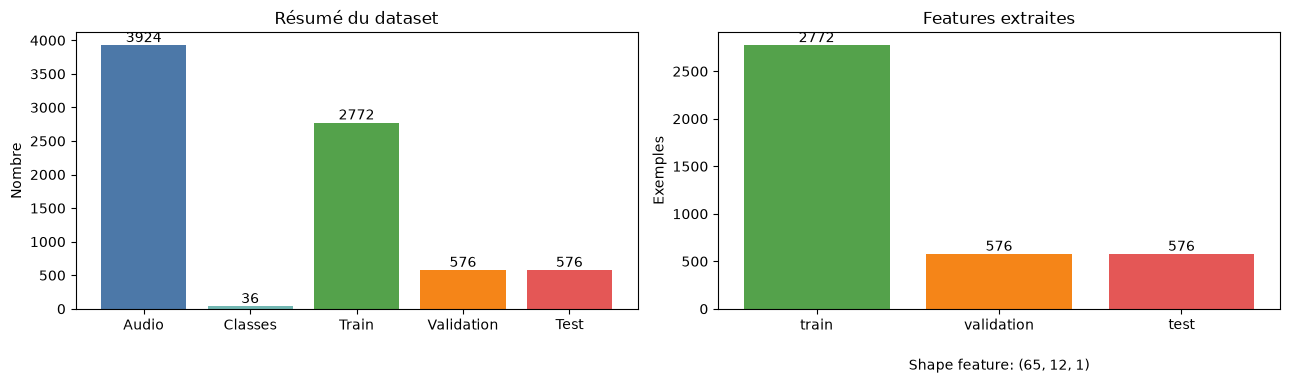

In [12]:
prepared = prepare_data(config)

summary_labels = ["Audio", "Classes", "Train", "Validation", "Test"]
summary_values = [
    len(prepared.dataset.audio_paths),
    len(prepared.dataset.labels),
    len(prepared.split.train_paths),
    len(prepared.split.val_paths),
    len(prepared.split.test_paths),
]
summary_colors = ["#4C78A8", "#72B7B2", "#54A24B", "#F58518", "#E45756"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(summary_labels, summary_values, color=summary_colors)
axes[0].set_title("Résumé du dataset")
axes[0].set_ylabel("Nombre")
axes[0].bar_label(axes[0].containers[0])

feature_shapes = {
    "train": prepared.x_train.shape[0],
    "validation": prepared.x_val.shape[0],
    "test": prepared.x_test.shape[0],
}
axes[1].bar(feature_shapes.keys(), feature_shapes.values(), color=["#54A24B", "#F58518", "#E45756"])
axes[1].set_title("Features extraites")
axes[1].set_ylabel("Exemples")
axes[1].bar_label(axes[1].containers[0])
axes[1].text(
    0.5,
    -0.22,
    f"Shape feature: {prepared.x_train.shape[1:]}",
    ha="center",
    transform=axes[1].transAxes,
)

plt.tight_layout()
plt.show()


## 3. Vérifier les splits

On contrôle rapidement la répartition train / validation / test.


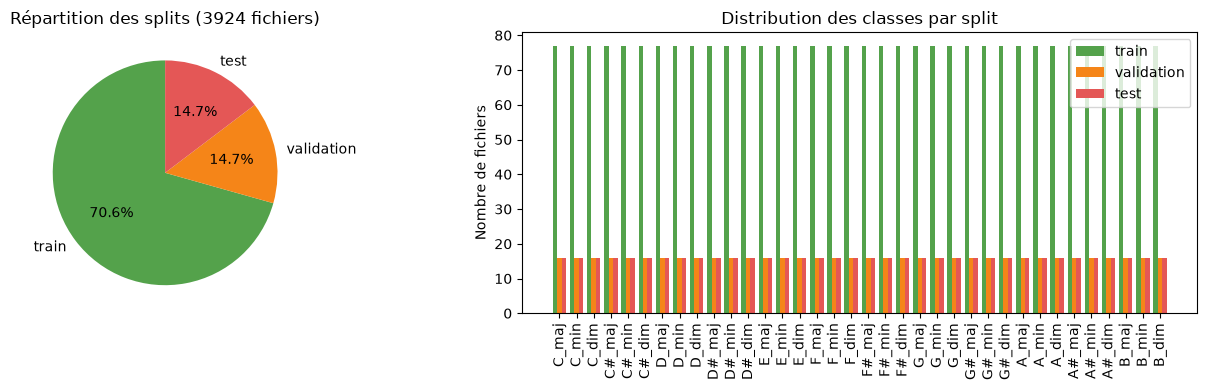

In [13]:
total_files = len(prepared.split.train_paths) + len(prepared.split.val_paths) + len(prepared.split.test_paths)

split_sizes = {
    "train": len(prepared.split.train_paths),
    "validation": len(prepared.split.val_paths),
    "test": len(prepared.split.test_paths),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].pie(
    split_sizes.values(),
    labels=split_sizes.keys(),
    autopct="%.1f%%",
    startangle=90,
    colors=["#54A24B", "#F58518", "#E45756"],
)
axes[0].set_title(f"Répartition des splits ({total_files} fichiers)")

split_counts = {}
for name, paths in (
    ("train", prepared.split.train_paths),
    ("validation", prepared.split.val_paths),
    ("test", prepared.split.test_paths),
):
    split_counts[name] = np.array([
        sum(prepared.dataset.label_from_path(path) == label for path in paths)
        for label in prepared.dataset.labels
    ])

x = np.arange(len(prepared.dataset.labels))
width = 0.26
axes[1].bar(x - width, split_counts["train"], width, label="train", color="#54A24B")
axes[1].bar(x, split_counts["validation"], width, label="validation", color="#F58518")
axes[1].bar(x + width, split_counts["test"], width, label="test", color="#E45756")
axes[1].set_xticks(x)
axes[1].set_xticklabels(prepared.dataset.labels, rotation=90)
axes[1].set_ylabel("Nombre de fichiers")
axes[1].set_title("Distribution des classes par split")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Visualiser une feature

Exemple de représentation Chroma-CQT utilisée par le modèle.


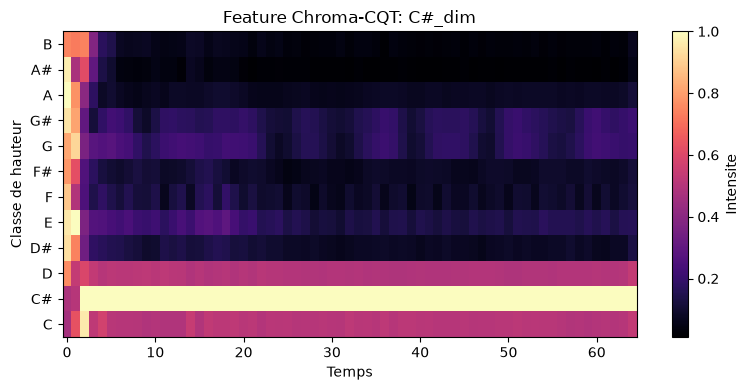

In [14]:
example_index = 0
plt.figure(figsize=(8, 4))
plt.imshow(prepared.x_train[example_index, :, :, 0].T, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Intensite")
plt.yticks(range(config.n_chroma), ROOTS)
plt.xlabel("Temps")
plt.ylabel("Classe de hauteur")
plt.title(f"Feature Chroma-CQT: {prepared.dataset.label_from_path(prepared.split.train_paths[example_index])}")
plt.tight_layout()
plt.show()

## 5. Entraîner le modèle

Le modèle est entraîné ou repris depuis le cache si le run existe déjà.


2026-07-10 09:04:54.596 | INFO     | musica.modeling.training:signature:159 - Signature du run: bddbd88ac5d1
2026-07-10 09:04:54.596 | INFO     | musica.modeling.training:load_cached_model:166 - Verification du cache modele: /Users/raharison/docs/projects/musica/logs/models/bddbd88ac5d1/best_model.keras
2026-07-10 09:04:54.597 | INFO     | musica.modeling.training:load_cached_model:168 - Cache hit: chargement de /Users/raharison/docs/projects/musica/logs/models/bddbd88ac5d1/best_model.keras


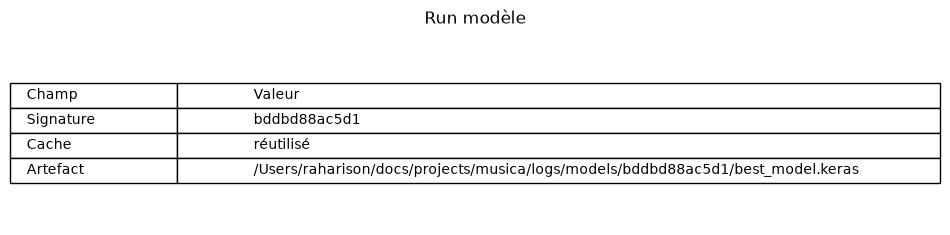

In [15]:
trainer = ChordTrainer(config, prepared.dataset)
training = trainer.train_or_load(prepared)

run_labels = ["Signature", "Cache", "Artefact"]
run_values = [
    training.signature,
    "réutilisé" if training.cache_hit else "entraîné",
    str(training.model_path),
]

fig, ax = plt.subplots(figsize=(12, 2.4))
ax.axis("off")
table = ax.table(
    cellText=[[label, value] for label, value in zip(run_labels, run_values, strict=True)],
    colLabels=["Champ", "Valeur"],
    loc="center",
    cellLoc="left",
    colLoc="left",
    colWidths=[0.18, 0.82],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
ax.set_title("Run modèle", pad=12)
plt.show()


## 6. Courbes d'entraînement

On affiche l'accuracy et la loss.


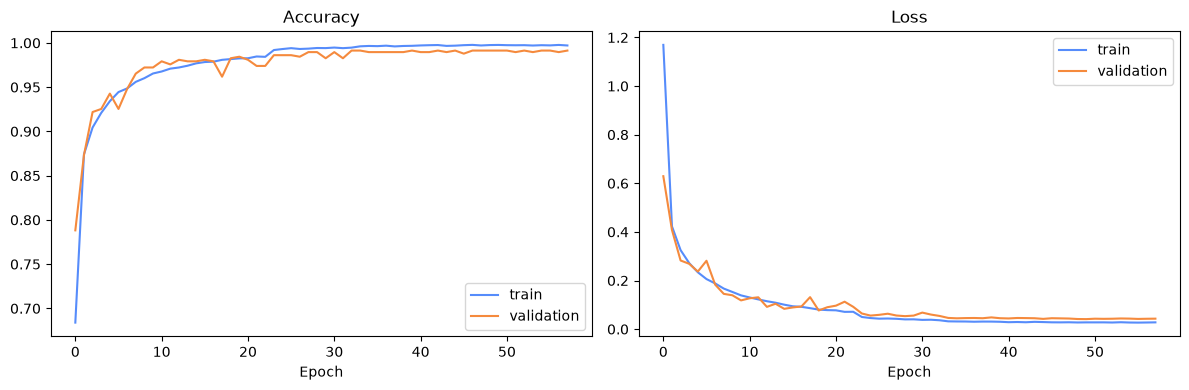

In [16]:
log_data = np.genfromtxt(training.history_log_path, delimiter=",", names=True)
curves = {name: np.atleast_1d(log_data[name]) for name in log_data.dtype.names}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(curves["accuracy"], label="train")
axes[0].plot(curves["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(curves["loss"], label="train")
axes[1].plot(curves["val_loss"], label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Évaluer le modèle

On mesure les performances sur le test et on affiche la matrice de confusion.


2026-07-10 09:04:54.792 | INFO     | musica.modeling.evaluation:evaluate:30 - Evaluation sur le test: 576 exemples
2026-07-10 09:04:55.171 | INFO     | musica.modeling.evaluation:evaluate:40 - Evaluation terminee: accuracy=0.9948, loss=0.0380, f1_macro=0.9948


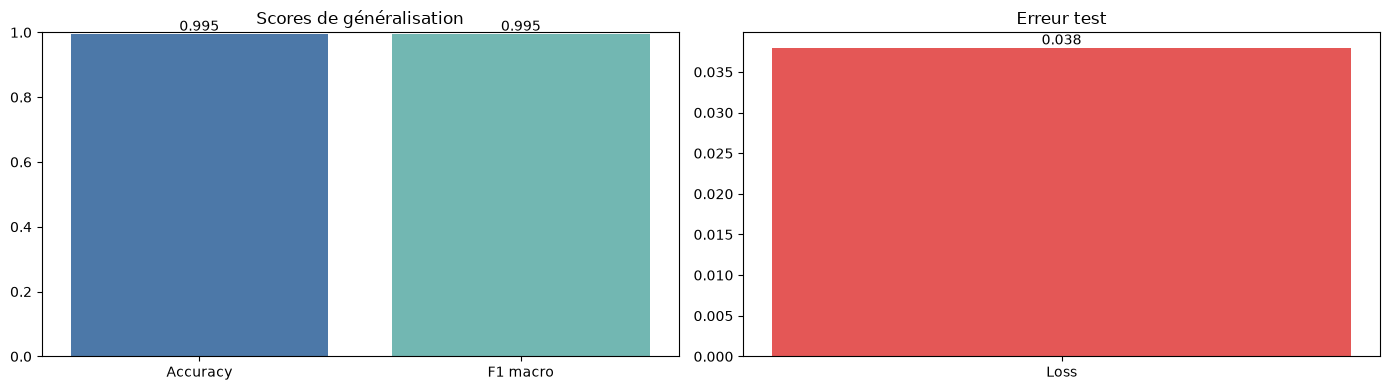

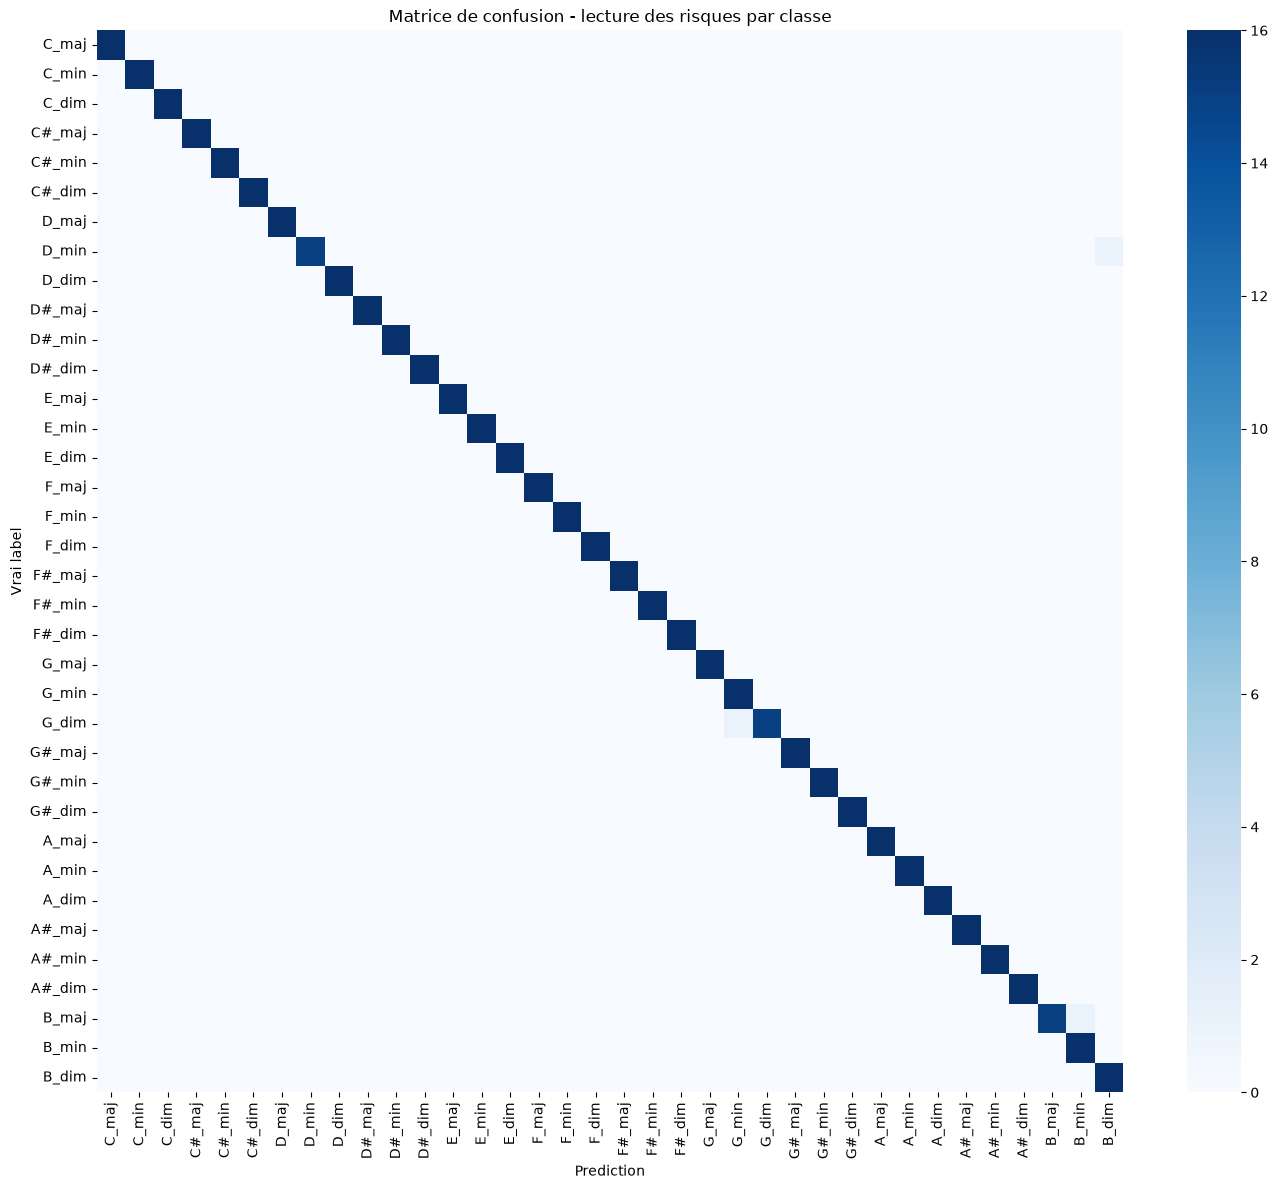

In [17]:
evaluator = ChordEvaluator()
evaluation = evaluator.evaluate(training.model, prepared.x_test, prepared.y_test, prepared.dataset.labels)

y_pred_proba = training.model.predict(prepared.x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
metric_names = ["Accuracy", "F1 macro"]
metric_values = [evaluation.test_accuracy, evaluation.f1_macro]
axes[0].bar(metric_names, metric_values, color=["#4C78A8", "#72B7B2"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Scores de généralisation")
axes[0].bar_label(axes[0].containers[0], fmt="%.3f")

axes[1].bar(["Loss"], [evaluation.test_loss], color="#E45756")
axes[1].set_title("Erreur test")
axes[1].bar_label(axes[1].containers[0], fmt="%.3f")
plt.tight_layout()
plt.show()

cm = confusion_matrix(prepared.y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=prepared.dataset.labels, yticklabels=prepared.dataset.labels)
plt.xlabel("Prediction")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion - lecture des risques par classe")
plt.tight_layout()
plt.show()


## 8. Prédire un accord

On teste le modèle sur le fichier audio configuré.


2026-07-10 09:04:55.489 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/E_maj.wav
2026-07-10 09:04:55.567 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/G_maj.wav


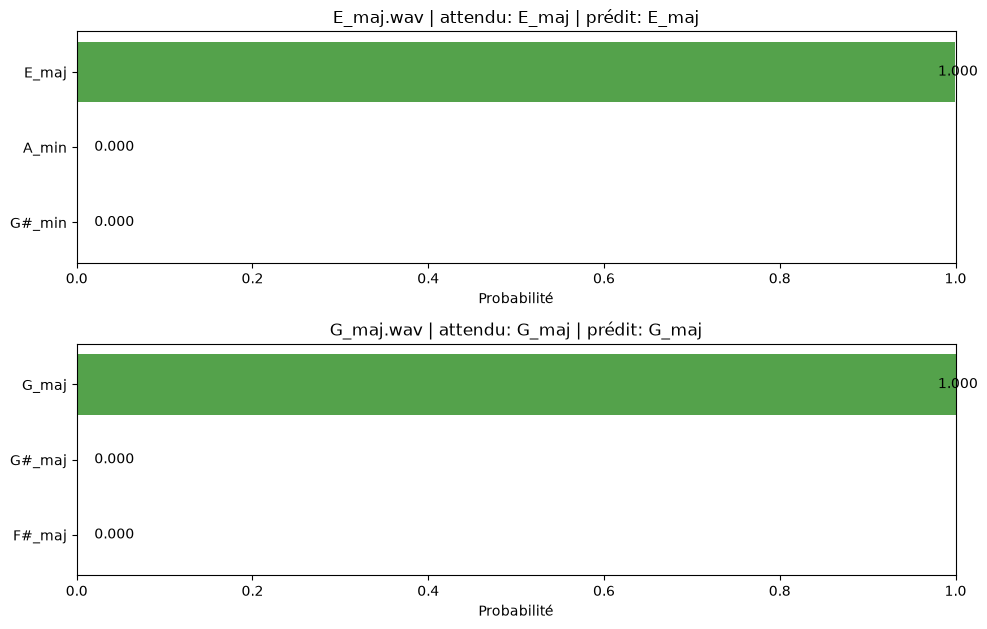

In [18]:
predictor = ChordPredictor(config, FeatureExtractor(config, prepared.dataset), prepared.dataset.labels)
example_audio_files = config.examples.audio_paths(Path.cwd())

fig, axes = plt.subplots(len(example_audio_files), 1, figsize=(10, 3.2 * len(example_audio_files)))
axes = np.atleast_1d(axes)

for ax, audio_path in zip(axes, example_audio_files, strict=True):
    predictions = predictor.predict(training.model, audio_path)
    labels = [label for label, _ in predictions]
    probabilities = [probability for _, probability in predictions]
    expected_label = prepared.dataset.label_from_path(audio_path)
    predicted_label = labels[0]
    colors = ["#54A24B" if label == predicted_label else "#4C78A8" for label in labels]

    ax.barh(labels[::-1], probabilities[::-1], color=colors[::-1])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Probabilité")
    ax.set_title(
        f"{audio_path.name} | attendu: {expected_label} | prédit: {predicted_label}"
    )
    for index, probability in enumerate(probabilities[::-1]):
        ax.text(min(probability + 0.02, 0.98), index, f"{probability:.3f}", va="center")

plt.tight_layout()
plt.show()
